In [1]:
import os
import re
import glob
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import hypergeom, spearmanr

In [2]:
INPUT = "/kaggle/input/datasets/nocturnalnerd18"
OUT_DIR = "/kaggle/working/dla_llava_analysis"
os.makedirs(OUT_DIR, exist_ok=True)

TYPES = ["attribute", "object", "relation"]
N_LAYER, N_HEAD = 32, 32
N_COMP = N_LAYER * N_HEAD + N_LAYER + 1


def batch_number(path):
    return int(re.search(r"_batch_(\d+)\.pt$", path).group(1))


meta, attn, mlp, embed, logit_diff = [], [], [], [], []
for t in TYPES:
    for path in sorted(glob.glob(f"{INPUT}/dla-llava/{t}_batch_*.pt"), key=batch_number):
        for e in torch.load(path):
            meta.append({k: e[k] for k in ("question_id", "hallucination_type", "ground_truth_answer")})
            attn.append(e["attn"] / e["rms"])
            mlp.append(e["mlp"] / e["rms"])
            embed.append((e["embed"] / e["rms"]).item())
            logit_diff.append(e["logit_diff"].item())

dla = pd.DataFrame(meta)
dla["row"] = np.arange(len(dla))
dla["logit_diff"] = logit_diff
FEATURES = np.concatenate([
    torch.stack(attn).reshape(len(dla), -1).numpy(),
    torch.stack(mlp).numpy(),
    np.array(embed, dtype=np.float32)[:, None],
], axis=1).astype(np.float32)

completeness_err = np.abs(FEATURES.sum(1) - dla["logit_diff"].to_numpy()).max()
print(len(dla), "dla entries,", FEATURES.shape[1], "components each")
print(f"components vs model logit diff, max abs err: {completeness_err:.4f}")
assert completeness_err < 0.5, "components do not reproduce the logit difference"

17134 dla entries, 1057 components each
components vs model logit diff, max abs err: 0.0175


In [3]:
with open(f"{INPUT}/vlm-labeled-examples/labeled_examples.json") as f:
    labels = pd.DataFrame(json.load(f))
assert "cache" in labels.columns, "attach vlm-labeled-examples version 3"
labels = labels[labels["cache"] == "question_aware"][["question_id", "source", "split", "model_answer"]]

df = dla.merge(labels, on="question_id", how="inner")
print(len(dla), "dla entries,", len(labels), "labeled yes/no questions,", len(df), "joined")
assert len(df) == len(labels), "labeled questions missing from dla"

df["truth"] = df["ground_truth_answer"].str.strip().str.lower()
df["group"] = np.select(
    [
        (df.truth == "yes") & (df.model_answer == "yes"),
        (df.truth == "no") & (df.model_answer == "no"),
        (df.truth == "no") & (df.model_answer == "yes"),
        (df.truth == "yes") & (df.model_answer == "no"),
    ],
    ["true_yes", "true_no", "false_yes", "false_no"],
    default="other",
)
assert (df.group != "other").all()

agree = ((df.logit_diff > 0) == (df.model_answer == "yes")).mean()
print(f"sign of logit_diff agrees with model_answer: {agree:.4f}")
assert agree > 0.95, "logit_diff disagrees with the cached answers"

print(pd.crosstab([df.hallucination_type, df.source, df.split], df.group))

17134 dla entries, 17126 labeled yes/no questions, 17126 joined
sign of logit_diff agrees with model_answer: 1.0000
group                              false_no  false_yes  true_no  true_yes
hallucination_type source   split                                        
attribute          amber    test         39        262      305       529
                            train       211       1207     1463      2460
                            val          39        267      305       533
object             pope     test         20         27      198       205
                            train        84        135      915       966
                            val          21         32      193       204
relation           amber    test         42         14       83       107
                            train       232        107      377       447
                            val          50         24       84        97
                   reefknot test         80        192      175       

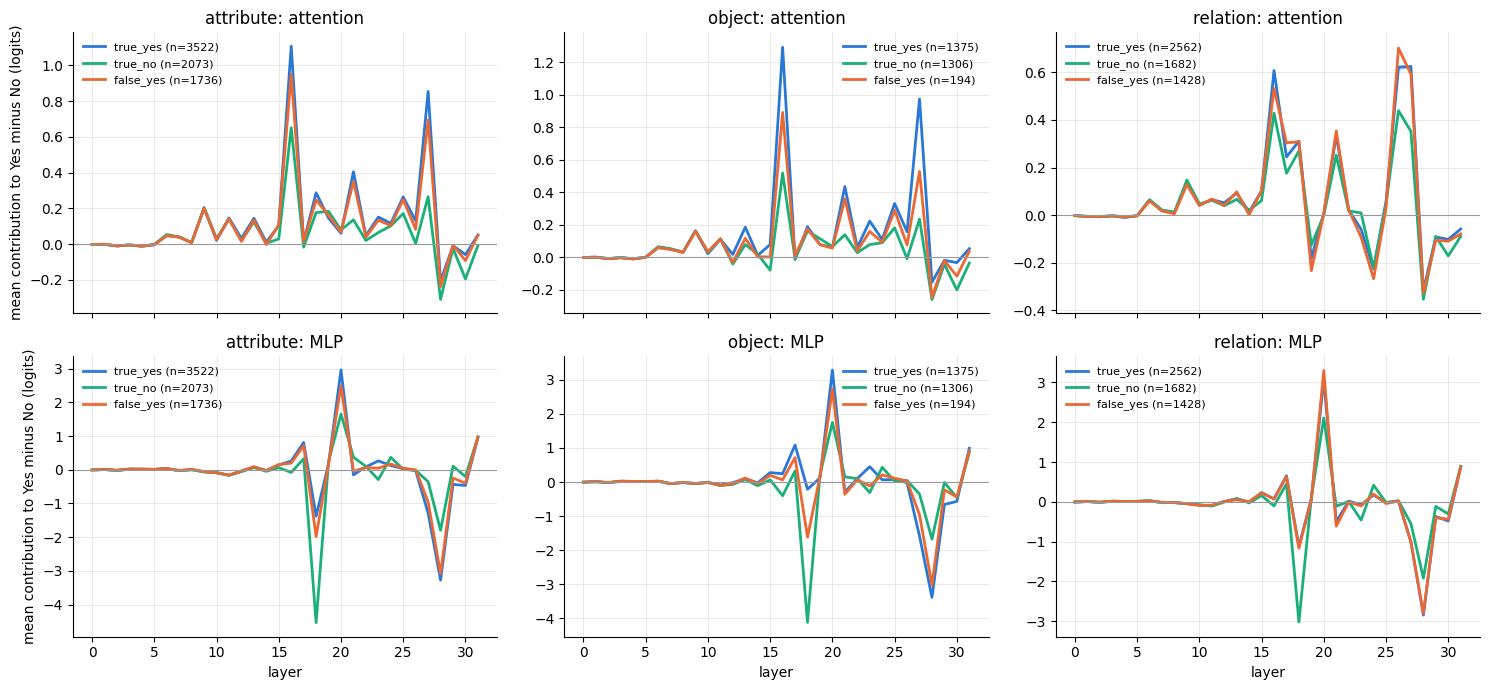

In [4]:
GROUP_COLORS = {"true_yes": "#2a78d6", "true_no": "#1baf7a", "false_yes": "#eb6834"}
layer_axis = np.arange(N_LAYER)
attn_layer = FEATURES[:, :N_LAYER * N_HEAD].reshape(-1, N_LAYER, N_HEAD).sum(2)
mlp_layer = FEATURES[:, N_LAYER * N_HEAD:N_LAYER * N_HEAD + N_LAYER]

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
for col, t in enumerate(TYPES):
    for row, (name, arr) in enumerate([("attention", attn_layer), ("MLP", mlp_layer)]):
        ax = axes[row, col]
        for g, color in GROUP_COLORS.items():
            x = arr[df[(df.hallucination_type == t) & (df.group == g)].row.to_numpy()]
            if len(x) < 2:
                continue
            m, se = x.mean(0), x.std(0, ddof=1) / np.sqrt(len(x))
            ax.plot(layer_axis, m, color=color, lw=2, label=f"{g} (n={len(x)})")
            ax.fill_between(layer_axis, m - 1.96 * se, m + 1.96 * se, color=color, alpha=0.2, lw=0)
        ax.axhline(0, color="#999999", lw=0.8)
        ax.set_title(f"{t}: {name}")
        ax.grid(color="#e5e5e2", lw=0.6)
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(frameon=False, fontsize=8)
        if col == 0:
            ax.set_ylabel("mean contribution to Yes minus No (logits)")
        if row == 1:
            ax.set_xlabel("layer")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/layer_profiles.png", dpi=150)
plt.show()

In [5]:
MIN_GROUP = 10
N_PERM = 500
K_TOP = 20
CONTRASTS = {"flip": ("false_yes", "true_no"), "evidence": ("false_yes", "true_yes")}
UNITS = {
    "attribute": ("attribute", None),
    "object": ("object", None),
    "relation": ("relation", None),
    "relation/amber": ("relation", "amber"),
    "relation/reefknot": ("relation", "reefknot"),
}


def comp_name(i):
    if i < N_LAYER * N_HEAD:
        return f"L{i // N_HEAD} H{i % N_HEAD}"
    if i < N_LAYER * N_HEAD + N_LAYER:
        return f"L{i - N_LAYER * N_HEAD} MLP"
    return "embed"


def build_strata(halluc_type, source, g_a, g_b, splits):
    mask = df.hallucination_type.eq(halluc_type) & df.group.isin([g_a, g_b]) & df.split.isin(splits)
    if source is not None:
        mask &= df.source.eq(source)
    strata = []
    for _, sub in df[mask].groupby("source"):
        is_a = sub.group.eq(g_a).to_numpy()
        if is_a.sum() < MIN_GROUP or (~is_a).sum() < MIN_GROUP:
            continue
        X = FEATURES[sub.row.to_numpy()].astype(np.float64)
        strata.append((X, X ** 2, is_a))
    return strata


def effects(strata, masks):
    d_sum, m_sum, w_sum = np.zeros(N_COMP), np.zeros(N_COMP), 0.0
    for (X, X2, _), mask in zip(strata, masks):
        na, nb = mask.sum(), (~mask).sum()
        mf = mask.astype(np.float64)
        sa, sa2 = mf @ X, mf @ X2
        sb, sb2 = X.sum(0) - sa, X2.sum(0) - sa2
        ma, mb = sa / na, sb / nb
        va, vb = (sa2 - na * ma ** 2) / (na - 1), (sb2 - nb * mb ** 2) / (nb - 1)
        sp = np.sqrt(np.maximum(((na - 1) * va + (nb - 1) * vb) / (na + nb - 2), 0))
        w = na * nb / (na + nb)
        d_sum += w * (ma - mb) / np.maximum(sp, 1e-6)
        m_sum += w * (ma - mb)
        w_sum += w
    return d_sum / w_sum, m_sum / w_sum


def perm_null(strata, seed=0):
    rng = np.random.default_rng(seed)
    null = np.empty(N_PERM)
    for b in range(N_PERM):
        d, _ = effects(strata, [rng.permutation(mask) for _, _, mask in strata])
        null[b] = np.abs(d).max()
    return null

In [6]:
results = {}
for unit, (t, source) in UNITS.items():
    for cname, (g_a, g_b) in CONTRASTS.items():
        train = build_strata(t, source, g_a, g_b, ["train"])
        held = build_strata(t, source, g_a, g_b, ["val", "test"])
        if not train:
            print(f"{unit:18s} {cname:8s} not enough train examples, skipped")
            continue
        d_train, m_train = effects(train, [m for _, _, m in train])
        d_held = effects(held, [m for _, _, m in held])[0] if held else np.full(N_COMP, np.nan)
        null95 = float(np.quantile(perm_null(train), 0.95))
        n_a = int(sum(m.sum() for _, _, m in train))
        n_b = int(sum((~m).sum() for _, _, m in train))
        results[(unit, cname)] = {
            "d_train": d_train, "m_train": m_train, "d_held": d_held, "null95": null95, "n_a": n_a, "n_b": n_b,
        }
        print(f"{unit:18s} {cname:8s} train {g_a} {n_a} vs {g_b} {n_b} | null95 {null95:.3f} | "
              f"significant {int((np.abs(d_train) > null95).sum())}")

attribute          flip     train false_yes 1207 vs true_no 1463 | null95 0.157 | significant 649
attribute          evidence train false_yes 1207 vs true_yes 2460 | null95 0.143 | significant 546
object             flip     train false_yes 135 vs true_no 915 | null95 0.371 | significant 570
object             evidence train false_yes 135 vs true_yes 966 | null95 0.371 | significant 441
relation           flip     train false_yes 1008 vs true_no 1161 | null95 0.180 | significant 581
relation           evidence train false_yes 1008 vs true_yes 1784 | null95 0.162 | significant 186
relation/amber     flip     train false_yes 107 vs true_no 377 | null95 0.445 | significant 139
relation/amber     evidence train false_yes 107 vs true_yes 447 | null95 0.451 | significant 109
relation/reefknot  flip     train false_yes 901 vs true_no 784 | null95 0.194 | significant 594
relation/reefknot  evidence train false_yes 901 vs true_yes 1337 | null95 0.172 | significant 175


In [7]:
for (unit, cname), r in results.items():
    d_train, d_held = r["d_train"], r["d_held"]
    sig = np.abs(d_train) > r["null95"]
    same = np.sign(d_train) == np.sign(d_held)
    gap = r["m_train"].sum()
    top = np.argsort(-np.abs(d_train))[:K_TOP]
    explained = r["m_train"][top].sum() / gap if gap != 0 else np.nan
    print(f"--- {unit} / {cname}: {r['n_a']} vs {r['n_b']} train questions, mean logit gap {gap:+.3f} ---")
    print(f"significant on train: {sig.sum()} | same sign held-out: {(sig & same).sum()} | "
          f"top-{K_TOP} carry {explained:.2f} of the gap")
    table = pd.DataFrame({
        "component": [comp_name(i) for i in top[:10]],
        "d_train": d_train[top[:10]].round(2),
        "d_held": d_held[top[:10]].round(2),
        "logits": r["m_train"][top[:10]].round(3),
    })
    print(table.to_string(index=False))

--- attribute / flip: 1207 vs 1463 train questions, mean logit gap +3.007 ---
significant on train: 649 | same sign held-out: 648 | top-20 carry 0.98 of the gap
component  d_train  d_held  logits
  L21 H25     2.59    2.55   0.095
  L18 MLP     2.53    2.48   2.559
  L21 H14     2.50    2.44   0.107
  L27 MLP    -2.31   -2.18  -0.600
  L17 MLP     2.29    2.26   0.388
  L24 MLP    -2.28   -2.24  -0.201
  L28 MLP    -2.25   -2.22  -1.296
  L30 H31     2.10    2.04   0.101
  L31 H27     2.04    2.03   0.059
  L25 H28     1.98    1.91   0.057
--- attribute / evidence: 1207 vs 2460 train questions, mean logit gap -1.067 ---
significant on train: 546 | same sign held-out: 546 | top-20 carry 0.28 of the gap
component  d_train  d_held  logits
   L16 H0    -1.08   -0.97  -0.161
   L26 H4    -0.98   -0.99  -0.042
  L18 H27    -0.97   -0.84  -0.002
  L18 H26    -0.93   -0.93  -0.007
  L22 H10    -0.91   -0.97  -0.006
   L25 H5    -0.90   -0.87  -0.002
  L27 H12    -0.87   -0.87  -0.014
  L19 H20

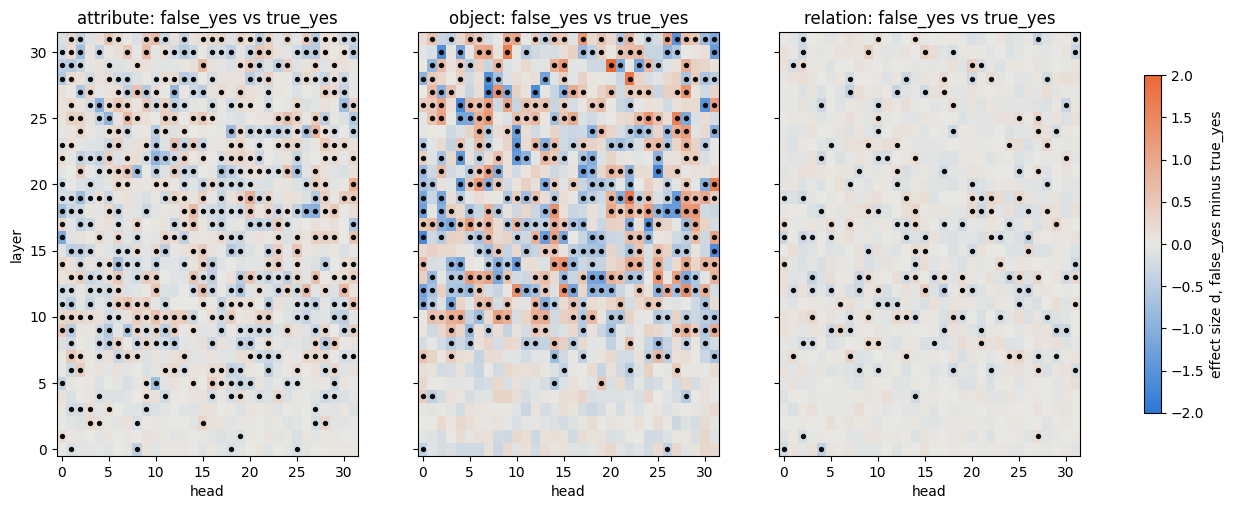

In [8]:
DIVERGING = LinearSegmentedColormap.from_list("dla_div", ["#2a78d6", "#e8e8e4", "#eb6834"])
plot_units = [u for u in TYPES if (u, "evidence") in results]
head_d = {u: results[(u, "evidence")]["d_train"][:N_LAYER * N_HEAD] for u in plot_units}
limit = max(np.abs(v).max() for v in head_d.values())

fig, axes = plt.subplots(1, len(plot_units), figsize=(5.5 * len(plot_units), 5.5), sharey=True, squeeze=False)
for ax, unit in zip(axes[0], plot_units):
    im = ax.imshow(head_d[unit].reshape(N_LAYER, N_HEAD), origin="lower", cmap=DIVERGING, vmin=-limit, vmax=limit, aspect="auto")
    sig = (np.abs(head_d[unit]) > results[(unit, "evidence")]["null95"]).reshape(N_LAYER, N_HEAD)
    ys, xs = np.nonzero(sig)
    ax.scatter(xs, ys, s=8, color="#0b0b0b")
    ax.set_title(f"{unit}: false_yes vs true_yes")
    ax.set_xlabel("head")
axes[0, 0].set_ylabel("layer")
fig.colorbar(im, ax=axes.ravel().tolist(), label="effect size d, false_yes minus true_yes", shrink=0.8)
plt.savefig(f"{OUT_DIR}/head_effects_evidence.png", dpi=150, bbox_inches="tight")
plt.show()

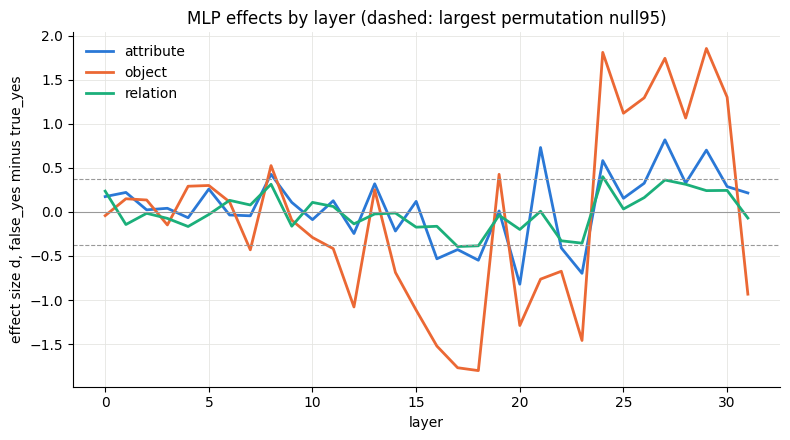

In [9]:
UNIT_COLORS = {"attribute": "#2a78d6", "object": "#eb6834", "relation": "#1baf7a"}

fig, ax = plt.subplots(figsize=(8, 4.5))
for unit in plot_units:
    r = results[(unit, "evidence")]
    ax.plot(layer_axis, r["d_train"][N_LAYER * N_HEAD:N_LAYER * N_HEAD + N_LAYER], color=UNIT_COLORS[unit], lw=2, label=unit)
null95 = max(results[(u, "evidence")]["null95"] for u in plot_units)
ax.axhline(0, color="#999999", lw=0.8)
ax.axhline(null95, color="#999999", lw=0.8, ls="--")
ax.axhline(-null95, color="#999999", lw=0.8, ls="--")
ax.set_xlabel("layer")
ax.set_ylabel("effect size d, false_yes minus true_yes")
ax.set_title("MLP effects by layer (dashed: largest permutation null95)")
ax.grid(color="#e5e5e2", lw=0.6)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/mlp_effects_evidence.png", dpi=150)
plt.show()

In [10]:
PAIRS = [
    ("attribute", "object"), ("attribute", "relation"), ("object", "relation"),
    ("relation/amber", "relation/reefknot"),
]

for cname in CONTRASTS:
    print(f"--- {cname}: top-{K_TOP} overlap and correlation of effect sizes ---")
    for a, b in PAIRS:
        if (a, cname) not in results or (b, cname) not in results:
            continue
        da, db = results[(a, cname)]["d_train"], results[(b, cname)]["d_train"]
        top_a, top_b = set(np.argsort(-np.abs(da))[:K_TOP]), set(np.argsort(-np.abs(db))[:K_TOP])
        overlap = len(top_a & top_b)
        p = hypergeom.sf(overlap - 1, N_COMP, K_TOP, K_TOP)
        print(f"{a:18s} vs {b:18s} overlap {overlap}/{K_TOP} (chance {K_TOP * K_TOP / N_COMP:.1f}, p {p:.4f}) | "
              f"spearman d {spearmanr(da, db)[0]:.3f} | spearman |d| {spearmanr(np.abs(da), np.abs(db))[0]:.3f}")

--- flip: top-20 overlap and correlation of effect sizes ---
attribute          vs object             overlap 14/20 (chance 0.4, p 0.0000) | spearman d 0.716 | spearman |d| 0.582
attribute          vs relation           overlap 13/20 (chance 0.4, p 0.0000) | spearman d 0.666 | spearman |d| 0.497
object             vs relation           overlap 12/20 (chance 0.4, p 0.0000) | spearman d 0.678 | spearman |d| 0.493
relation/amber     vs relation/reefknot  overlap 13/20 (chance 0.4, p 0.0000) | spearman d 0.388 | spearman |d| 0.241
--- evidence: top-20 overlap and correlation of effect sizes ---
attribute          vs object             overlap 6/20 (chance 0.4, p 0.0000) | spearman d 0.579 | spearman |d| 0.425
attribute          vs relation           overlap 3/20 (chance 0.4, p 0.0054) | spearman d 0.313 | spearman |d| 0.283
object             vs relation           overlap 9/20 (chance 0.4, p 0.0000) | spearman d 0.401 | spearman |d| 0.280
relation/amber     vs relation/reefknot  overlap 0/

In [11]:
shortlist = {}
for (unit, cname), r in results.items():
    d_train, d_held = r["d_train"], r["d_held"]
    keep = [
        i for i in np.argsort(-np.abs(d_train))
        if abs(d_train[i]) > r["null95"] and np.sign(d_train[i]) == np.sign(d_held[i])
    ]
    shortlist[f"{unit}/{cname}"] = [
        {"component": comp_name(i), "index": int(i), "d_train": float(d_train[i]),
         "d_held": float(d_held[i]), "logits_train": float(r["m_train"][i])}
        for i in keep[:30]
    ]
    print(f"{unit:18s} {cname:8s} shortlisted {len(shortlist[f'{unit}/{cname}'])}")

with open(f"{OUT_DIR}/shortlist.json", "w") as f:
    json.dump(shortlist, f)

with open(f"{OUT_DIR}/effects.json", "w") as f:
    json.dump({
        f"{unit}/{cname}": {
            "d_train": r["d_train"].tolist(), "d_held": r["d_held"].tolist(), "m_train": r["m_train"].tolist(),
            "null95": r["null95"], "n_a": r["n_a"], "n_b": r["n_b"],
        }
        for (unit, cname), r in results.items()
    }, f)

attribute          flip     shortlisted 30
attribute          evidence shortlisted 30
object             flip     shortlisted 30
object             evidence shortlisted 30
relation           flip     shortlisted 30
relation           evidence shortlisted 30
relation/amber     flip     shortlisted 30
relation/amber     evidence shortlisted 30
relation/reefknot  flip     shortlisted 30
relation/reefknot  evidence shortlisted 30


In [12]:
USERNAME = "nocturnalnerd18"

with open(os.path.join(OUT_DIR, "dataset-metadata.json"), "w") as f:
    json.dump({
        "title": "dla-llava-analysis",
        "id": f"{USERNAME}/dla-llava-analysis",
        "subtitle": "DLA effect sizes and shortlisted components for LLaVA",
        "description": "Effect sizes (Cohen's d, pooled over sources) for every attention head, MLP layer and the embedding "
                       "on the false_yes vs true_no (flip) and false_yes vs true_yes (evidence) contrasts, ranked on the train split "
                       "and checked on val and test. effects.json holds the full vectors, indexed as layer * 32 + head for heads, "
                       "1024 + layer for MLPs and 1056 for the embedding. shortlist.json holds the components that pass a "
                       "max-statistic permutation null on train and keep their sign on held-out data.",
        "licenses": [{"name": "CC0-1.0"}],
    }, f)

!kaggle datasets create -p {OUT_DIR}

Starting upload for file shortlist.json
100%|██████████████████████████████████████| 41.1k/41.1k [00:00<00:00, 56.3kB/s]
Upload successful: shortlist.json (41KB)
Starting upload for file mlp_effects_evidence.png
100%|█████████████████████████████████████████| 120k/120k [00:00<00:00, 125kB/s]
Upload successful: mlp_effects_evidence.png (120KB)
Starting upload for file layer_profiles.png
100%|█████████████████████████████████████████| 331k/331k [00:01<00:00, 253kB/s]
Upload successful: layer_profiles.png (331KB)
Starting upload for file effects.json
100%|█████████████████████████████████████████| 683k/683k [00:01<00:00, 410kB/s]
Upload successful: effects.json (683KB)
Starting upload for file head_effects_evidence.png
100%|█████████████████████████████████████████| 201k/201k [00:01<00:00, 201kB/s]
Upload successful: head_effects_evidence.png (201KB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/nocturnalnerd18/dla-llava-analysis
